In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pandas.plotting import scatter_matrix
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import PowerTransformer, PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
# load the data and take a peek
df = pd.read_csv("../01_stroke/stroke_data.csv")
# replace the stroke column with a boolean
df.replace({"Stroke": ["Y","N"]}, {"Stroke": [True,False]}, inplace=True)

/tmp/ipykernel_331639/3927382883.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Stroke": ["Y","N"]}, {"Stroke": [True,False]}, inplace=True)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Stroke                       126 non-null    bool   
 1   NASCET                       126 non-null    int64  
 2   CALCVol                      126 non-null    float64
 3   CALCVolProp                  126 non-null    float64
 4   MATXVol                      126 non-null    float64
 5   MATXVolProp                  126 non-null    float64
 6   LRNCVol                      126 non-null    float64
 7   LRNCVolProp                  126 non-null    float64
 8   MaxCALCArea                  126 non-null    float64
 9   MaxCALCAreaProp              126 non-null    float64
 10  MaxDilationByArea            126 non-null    float64
 11  MaxMATXArea                  126 non-null    float64
 12  MaxMATXAreaProp              126 non-null    float64
 13  MaxLRNCArea         

In [4]:
# select 30% to set aside, stratified by stroke
p = 0.3
# Super important to seed your random number generator for reproducibility
rng = np.random.default_rng(42) # yes, this is an over-used random number seed
n_test = int(p * len(df))
is_stroke = df["Stroke"] == "Y"
not_stroke = df["Stroke"] == "N"
n_stroke = int(p * is_stroke.sum())
test_ids = np.hstack([rng.choice(np.where(is_stroke)[0], n_stroke),
                     rng.choice(np.where(~is_stroke)[0], n_test - n_stroke)])
train_ids = np.delete(np.arange(len(df)), test_ids)
test = df.iloc[test_ids]
train = df.iloc[train_ids]

In [5]:
# Group the imaging predictors and risk factors
VC_preds = ["CALCVol", "CALCVolProp", "MATXVol", "MATXVolProp", "LRNCVol", 
    "LRNCVolProp", "MaxCALCArea", "MaxCALCAreaProp", "MaxDilationByArea", 
    "MaxMATXArea", "MaxMATXAreaProp", "MaxLRNCArea", "MaxLRNCAreaProp", 
    "MaxMaxWallThickness", "MaxRemodelingRatio", "MaxStenosisByArea", 
    "MaxWallArea", "WallVol", "MaxStenosisByDiameter"]
risk_preds = ["age", "sex", "SmokingHistory", "AtrialFibrillation", "CoronaryArteryDisease", 
    "DiabetesHistory", "HypercholesterolemiaHistory", "HypertensionHistory"]

In [6]:
df[risk_preds].head()

,age,sex,SmokingHistory,AtrialFibrillation,CoronaryArteryDisease,DiabetesHistory,HypercholesterolemiaHistory,HypertensionHistory
0,72,1,1,0,0,0,0,1
1,76,1,1,0,0,1,1,1
2,72,0,0,0,0,0,0,0
3,61,1,1,0,0,1,1,1
4,65,1,0,0,0,0,0,1


In [7]:
im_corr = train[VC_preds].corr().values
# print out features that are off-diagonal but have high correlation
corr_thresh  = 0.9
exclude = []
scatter_check = []
for i in range(len(VC_preds)):
    for j in range(len(VC_preds)):
        if i < j and abs(im_corr[i, j]) > corr_thresh:
            print(f"{VC_preds[i]} is correlated with {VC_preds[j]}")
            exclude.append(VC_preds[i])
            scatter_check += [VC_preds[i], VC_preds[j]]
            
# filter the VC_preds list
im_preds = [p for p in VC_preds if p not in exclude]

MATXVol is correlated with WallVol
MaxMATXArea is correlated with MaxWallArea
MaxStenosisByArea is correlated with MaxStenosisByDiameter


In [63]:
# imaging feature pipeline
im_process = make_pipeline(
    PolynomialFeatures(degree=2),
    StandardScaler(),
)


preprocess = make_column_transformer(
    (im_process, VC_preds),
    ("passthrough", risk_preds[1:])
).set_output(transform="pandas")
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...), ('passthrough', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [64]:
print(train.shape)
train_pro = preprocess.fit_transform(train)
print(train_pro.shape)
train_pro.head()


(94, 29)
(94, 217)


,pipeline__1,pipeline__CALCVol,pipeline__CALCVolProp,pipeline__MATXVol,pipeline__MATXVolProp,pipeline__LRNCVol,pipeline__LRNCVolProp,pipeline__MaxCALCArea,pipeline__MaxCALCAreaProp,pipeline__MaxDilationByArea,...,pipeline__WallVol^2,pipeline__WallVol MaxStenosisByDiameter,pipeline__MaxStenosisByDiameter^2,passthrough__sex,passthrough__SmokingHistory,passthrough__AtrialFibrillation,passthrough__CoronaryArteryDisease,passthrough__DiabetesHistory,passthrough__HypercholesterolemiaHistory,passthrough__HypertensionHistory
0,0.0,0.143242,-0.090572,0.159661,-0.296229,-0.492838,-0.254561,-0.607092,0.221971,0.163095,...,-0.023750,-2.120025,-1.505801,1,1,0,0,0,0,1
1,0.0,-0.750411,-0.928998,-0.008710,0.603498,0.012459,0.340549,-1.006456,-0.885162,-0.427964,...,-0.281841,-1.831229,-1.428068,1,1,0,0,1,1,1
2,0.0,-0.391005,-0.590453,1.080987,0.084374,-0.154234,-0.366199,-0.305921,0.530369,-0.181153,...,0.760922,-1.587241,-1.414332,0,0,0,0,0,0,0
3,0.0,2.535320,2.118169,0.651356,-0.277149,-0.789478,-1.073201,3.294894,1.729736,2.571966,...,0.731513,-1.565143,-1.407054,1,1,0,0,1,1,1
4,0.0,-0.519687,-0.539441,-0.066549,-0.466384,-0.252308,-0.472157,-0.206716,-0.095159,-0.423234,...,-0.163935,-0.565570,-0.743597,1,0,0,0,0,0,1


## Manual feature selection
There is a big problem with this approach!

In [65]:
# look at correlation by predictor
corr_coeffs = np.zeros(train_pro.shape[1])
for i, pred in enumerate(train_pro.columns):
    corr_coeffs[i] = np.corrcoef(train_pro[pred], train["Stroke"])[0][1]

/home/ccurtis/Documents/Teaching/mru-data3464/w26/venv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ccurtis/Documents/Teaching/mru-data3464/w26/venv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 50 by absolute correlation (linear relationship with stroke):
pipeline__1: correlation = nan
pipeline__MaxStenosisByArea WallVol: correlation = 0.32
pipeline__LRNCVolProp MaxRemodelingRatio: correlation = 0.32
pipeline__WallVol MaxStenosisByDiameter: correlation = 0.32
pipeline__MaxLRNCArea MaxStenosisByDiameter: correlation = 0.31
pipeline__MATXVol MaxStenosisByArea: correlation = 0.30
pipeline__MATXVol MaxStenosisByDiameter: correlation = 0.30
pipeline__MaxLRNCArea MaxStenosisByArea: correlation = 0.29
pipeline__MaxRemodelingRatio WallVol: correlation = 0.28
pipeline__MATXVolProp MaxLRNCArea: correlation = 0.28
pipeline__MaxCALCArea MaxLRNCArea: correlation = 0.28
pipeline__MaxLRNCArea: correlation = 0.27
pipeline__LRNCVol MaxRemodelingRatio: correlation = 0.27
pipeline__MaxMATXAreaProp MaxLRNCArea: correlation = 0.27
pipeline__MATXVol MaxRemodelingRatio: correlation = 0.27
pipeline__MaxStenosisByArea MaxWallArea: correlation = 0.27
pipeline__MaxWallArea MaxStenosisByDiameter: co

<BarContainer object of 217 artists>

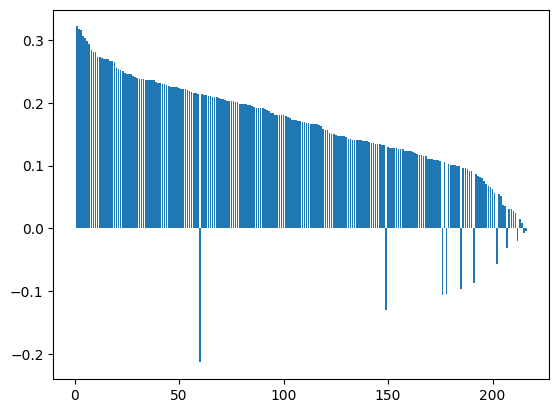

In [66]:
# sort and print out the correlation coefficients
corr_order = np.argsort(np.abs(corr_coeffs))[::-1]

print(f"Top {N} by absolute correlation (linear relationship with stroke):")
for idx in corr_order:
    print(f"{train_pro.columns[idx]}: correlation = {corr_coeffs[idx]:.2f}")

plt.bar(np.arange(len(corr_coeffs)), corr_coeffs[corr_order])


In [62]:
# compose the pipeline with predictor
pipeline = make_pipeline(
    preprocess,
    make_column_transformer(
        ("passthrough", train_pro.columns[corr_order[:40]]),
    ),
    LinearSVC(),
)

cv = cross_val_score(pipeline, X=train, y=train["Stroke"])
cv  

array([0.57894737, 0.63157895, 0.68421053, 0.52631579, 0.72222222])